In [6]:
# Import Necessary Libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


## Convolutional Operation


In [ ]:
# input
x = torch.arange(25).reshape(1,1,5,5).float()

# conv layer
conv = nn.Conv2d(in_channels=1,out_channels=1, kernel_size=3,bias=False)

# kernel
kernel = torch.tensor([
    [0.,1.,2.],
    [3.,4.,5.],
    [0.,1.,2.]
]).reshape(1,1,3,3)

# Assign the kernel to conv operation
conv.weight.data = kernel

output = conv(x)

## Calculate the Number of Parameters


In [ ]:
# Define Convolution Operation
conv = nn.Conv2d(in_channels=3,out_channels=1, kernel_size=3,bias=False)

def count_parameters(model):
    """
    model: nn.Conv2D
    Calculates number of trainable parameters in given pytorch module
    """
    # Tensor.numel() -- > Return Total Number of Elements in Tensor
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(count_parameters(conv))

## Build a simple CNN

In [ ]:
"""
Andrew Ng says that batch normalization should be applied immediately before the non-linearity of the current layer. 
The authors of the BN paper said that as well. : https://arxiv.org/pdf/1502.03167

According to François Chollet on the keras thread, the BN paper authors use BN after the activation layer
https://github.com/keras-team/keras/issues/1802#issuecomment-187966878
"""

class NeuralNetwork(nn.Module):
    def __init__(self,input_channels,output_channels,num_classes):
        super().__init__()

        #
        self.num_classes = num_classes

        self.conv_1       = nn.Conv2d(input_channels,output_channels,kernel_size=5)
        self.relu_1       = nn.ReLU()
        self.batch_norm_1 = nn.BatchNorm2d(num_features=output_channels)
        self.max_pool_1   = nn.MaxPool2d(kernel_size=2) 


        self.conv_2 = nn.Conv2d(output_channels,out_channels= 256,kernel_size=3)
        self.relu_2 = nn.ReLU()
        self.batch_norm_2 = nn.BatchNorm2d(256)
        self.max_pool_2   = nn.MaxPool2d(kernel_size=2) 

        # self.linear_1 = nn.Linear(in_features=300,out_features=64)
        self.linear_1 = nn.Linear(in_features=256 * 54 * 54,out_features=num_classes)
        self.softmax = torch.nn.Softmax()

    def forward(self,x):
        
        x = self.max_pool_1(self.relu_1(self.batch_norm_1(self.conv_1(x)))) 
        x = self.max_pool_2(self.relu_2(self.batch_norm_2(self.conv_2(x))))

        x = x.view(x.shape[0],-1) # [4, 746496]

        x = self.linear_1(x)

        return self.softmax(x)


        


# torch.Size([4, 64, 220, 220]) (maxpool) -- > torch.Size([4, 64, 110, 110])

tiny_model = NeuralNetwork(input_channels=3,output_channels=64,num_classes=5) 
tensor = torch.randint(low=0,high=1,size= (4,3,224,224)).float()


tiny_model = NeuralNetwork(input_channels=3,output_channels=64,num_classes=5)

print(tiny_model(tensor))

tensor([[0.1999, 0.1999, 0.2000, 0.2001, 0.2001],
        [0.1999, 0.1999, 0.2000, 0.2001, 0.2001],
        [0.1999, 0.1999, 0.2000, 0.2001, 0.2001],
        [0.1999, 0.1999, 0.2000, 0.2001, 0.2001]], grad_fn=<SoftmaxBackward0>)


# Softmax Temperature Scaling

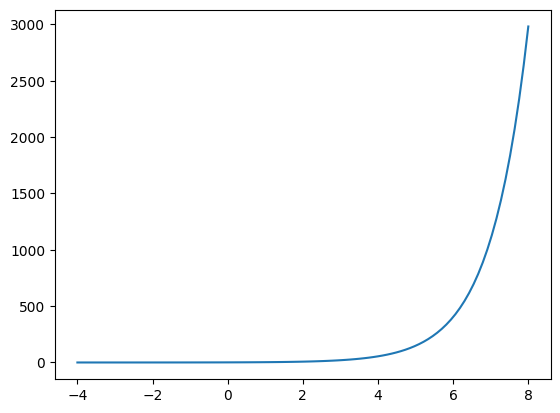

In [7]:
# create a logit array , low = -4, high = 8, N= 100
x = np.linspace(-4,8,100)

# Take the expotential of y
y = np.exp(x)

plt.plot(x,y)


In [ ]:
# Observe the difference between x values and expotential values
print(np.exp(2))
print(np.exp(4))

7.38905609893065


In [11]:
def softmax(logits,t=1.0):
    """Calculate Softmax Probability with Temperature"""

    exponetiated_logits = np.exp(logits/t)
    sum = np.sum(exponetiated_logits,axis=0)

    return exponetiated_logits/sum


In [14]:
#
logits = np.array([1.89,-1.24,-2.5])

In [15]:
# Temperature =1 , Same as normal softmax
softmax(logits,t=1.0)

array([0.94686342, 0.04139478, 0.0117418 ])

In [16]:
# Temperature =1.5
softmax(logits,t=1.5)

array([0.84913039, 0.10537718, 0.04549244])

In [17]:
# Temperature = 2.0
softmax(logits,t=2.0)

array([0.75731955, 0.15834644, 0.08433402])